# Loading Supermarket & Shopping list

In [1]:
from supermarket import Grid
from shopping_list import ShoppingList
import distance

grid = Grid("grid_eng.txt")
shopping_list = ShoppingList.load_from_file("Long_shopping_list.txt")
J_product_category, P_product_category, product_type_indizes = distance.compute_optimal_trajectories(grid, (5,4), (5,0))
J_product, P_product = distance.create_product_cost_path_matrix(shopping_list, J_product_category, P_product_category, product_type_indizes)


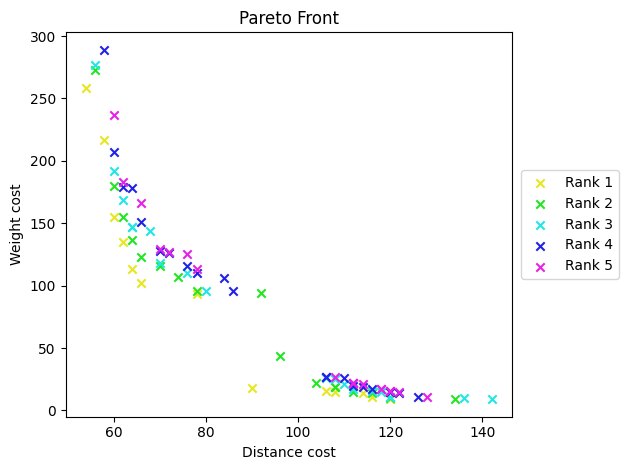

In [2]:
from shopping_list import ShoppingList
import order_functions

def compute_weight_cost(order, shopping_list: ShoppingList):
    """
    Crushing penalty:
    If a heavier product is packed later (thus lies on top)
    of a lighter product, a penalty proportional to the
    weight difference is added.
    
    Cost = 0  -> perfectly sorted heavy -> light
    """
    assert len(order) == len(shopping_list)

    total_cost = 0
    weights_list = []

    for i in range(len(order)):
        product_idx_bottom = order[i]-1 # -1 because order goes from 1 to n but in products we use the index, which starts with 0
        weight_bottom = shopping_list.products[product_idx_bottom].weight
        weights_list.append(weight_bottom)
        for j in range(i + 1, len(order)):
            product_idx_top = order[j]-1 # -1 because order goes from 1 to n but in products we use the index, which starts with 0
            weight_top = shopping_list.products[product_idx_top].weight

            # crushing condition: heavier on top of lighter
            if weight_top > weight_bottom:
                total_cost += (weight_top - weight_bottom)
    #print(f"Weights: {weights_list}")
    return total_cost


import random
def generate_weightgreedy_random_order(shopping_list: ShoppingList, alpha=0.5):
    products = shopping_list.products
    n = len(products)

    order = []
    remaining_product_indices = list(range(0, n))  # Produkt-Indizes

    for _ in range(n):
        # Gewichte der noch nicht gewählten Produkte
        weights = [products[i].weight for i in remaining_product_indices]

        max_weight = max(weights)
        min_weight = min(weights)

        # Für heavy-first: obere Grenze definieren
        cutoff_value = max_weight - alpha * (max_weight - min_weight)

        # RCL: alle Produkte mit Gewicht >= cutoff
        rcl = [i for i in remaining_product_indices 
               if products[i].weight >= cutoff_value]

        winner = random.choice(rcl)

        order.append(winner+1) # order number is index + 1 (because 0 == start)
        remaining_product_indices.remove(winner)
    return order



import numpy as np

def pareto_rank_2_with_crowding(cost1, cost2):
    """
    Computes Pareto ranks for two objectives (minimization) and sorts
    solutions within each front by crowding distance (descending).

    Returns:
        - final_ranking: list of indices sorted by Pareto rank and crowding distance
        - ranks: list of Pareto ranks for each solution (rank 0 = best front)
    """
    n = len(cost1)
    assert n == len(cost2)
    
    ranks = [-1] * n
    remaining = set(range(n))
    current_rank = 1
    fronts = []

    # Step 1: Identify Pareto fronts
    while remaining:
        current_front = []
        for i in remaining:
            dominated = False
            for j in remaining:
                if j == i:
                    continue
                if (cost1[j] <= cost1[i] and cost2[j] <= cost2[i]) and \
                   (cost1[j] < cost1[i] or cost2[j] < cost2[i]):
                    dominated = True
                    break
            if not dominated:
                current_front.append(i)

        for i in current_front:
            ranks[i] = current_rank
            remaining.remove(i)

        fronts.append(current_front)
        current_rank += 1

    # Step 2: Compute crowding distance for each front
    crowding_distances = np.zeros(n)
    for front in fronts:
        if len(front) == 1:
            crowding_distances[front[0]] = float('inf')
            continue

        front_cost1 = np.array([cost1[i] for i in front])
        front_cost2 = np.array([cost2[i] for i in front])
        
        # Sort by each objective
        sorted1 = np.argsort(front_cost1)
        sorted2 = np.argsort(front_cost2)
        
        # Boundaries get infinite distance
        crowding_distances[front[sorted1[0]]] = float('inf')
        crowding_distances[front[sorted1[-1]]] = float('inf')
        crowding_distances[front[sorted2[0]]] = float('inf')
        crowding_distances[front[sorted2[-1]]] = float('inf')
        
        # Normalize ranges
        norm1 = front_cost1.max() - front_cost1.min() or 1.0
        norm2 = front_cost2.max() - front_cost2.min() or 1.0

        # Interior points
        for k in range(1, len(front)-1):
            crowding_distances[front[sorted1[k]]] += (front_cost1[sorted1[k+1]] - front_cost1[sorted1[k-1]]) / norm1
            crowding_distances[front[sorted2[k]]] += (front_cost2[sorted2[k+1]] - front_cost2[sorted2[k-1]]) / norm2

    # Step 3: Produce final ranking (rank ascending, crowding distance descending)
    all_indices = list(range(n))
    final_ranking = sorted(all_indices, key=lambda i: (ranks[i], -crowding_distances[i]))

    return final_ranking, ranks, crowding_distances

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_pareto_2(ranks, costx, costy, xlabel = "Cost x", ylabel = "Cost y", max_legend_ranks=5, plot_high_ranks = True, reference_point = None, saving_path = None):
    """
    Uses pareto_rank_2 and plots Pareto fronts.
    
    - First max_legend_ranks fronts get distinct colors + legend entry
    - Remaining fronts are plotted in black with a single legend entry "Rank > max_legend_ranks-1"
    """
    max_rank = max(ranks)
    num_fronts = max_rank

    # Farben nur für die ersten expliziten Fronten erzeugen
    colors = [
        mcolors.hsv_to_rgb((i / max_legend_ranks, 0.85, 0.9))
        for i in range(max_legend_ranks)
    ]

    plt.figure()
    black_plotted = False  # Flag, damit schwarzes Label nur einmal in der Legende erscheint
    for r in range(1,num_fronts+1):
        indices = [i for i in range(len(ranks)) if ranks[i] == r]
        x_vals = [costx[i] for i in indices]
        y_vals = [costy[i] for i in indices]

        if r < max_legend_ranks:
            plt.scatter(
                x_vals,
                y_vals,
                color=colors[r],
                label=f"Rank {r}",
                marker="x"
            )
        elif plot_high_ranks:
            label = f"Rank ≥ {max_legend_ranks}" if not black_plotted else None
            plt.scatter(
                x_vals,
                y_vals,
                color="black",
                marker="x",
                label=label
            )
            black_plotted = True
    if reference_point is not None:
        plt.scatter(
            reference_point[0],
            reference_point[1],
            color="red",
            marker="x",
            s=100,
            label="Reference-point"
        )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title("Pareto Front")
    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0
        )
    plt.tight_layout()
    if saving_path is not None:
        plt.savefig(saving_path, bbox_inches="tight", dpi=300)


import distance
#order = order_functions.generate_random_order(len(shopping_list))
m = 1000
weight_costs, distance_costs = [], []
for i in range(m):
    if i < m/2:
        order = generate_weightgreedy_random_order(shopping_list, alpha = 0.5)
    else:
        order = order_functions.generate_distancegreedy_random_order(J_product, alpha = 0.5)
    weight_cost = compute_weight_cost(order, shopping_list)
    weight_costs.append(weight_cost)
    distance_cost = distance.compute_timecost_from_middle_indices_order(order, J_product)
    distance_costs.append(distance_cost)
import matplotlib.pyplot as plt
final_ranking, ranks, crowding_distances = pareto_rank_2_with_crowding(distance_costs, weight_costs)
plot_pareto_2(ranks, distance_costs, weight_costs, xlabel="Distance cost", ylabel="Weight cost", max_legend_ranks=6, plot_high_ranks=False)


In [3]:
import matplotlib.pyplot as plt
def plot_hypervolume(hypervolume_list, saving_path = None):
    fig = plt.figure()
    plt.plot(hypervolume_list)
    plt.xlabel("Generation")
    plt.ylabel("Relative Hypervolume in %")
    if saving_path is not None:
        plt.savefig(saving_path, bbox_inches="tight", dpi=300)
    

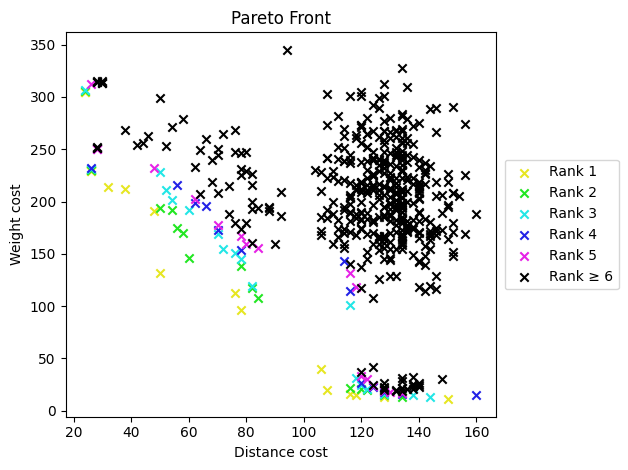

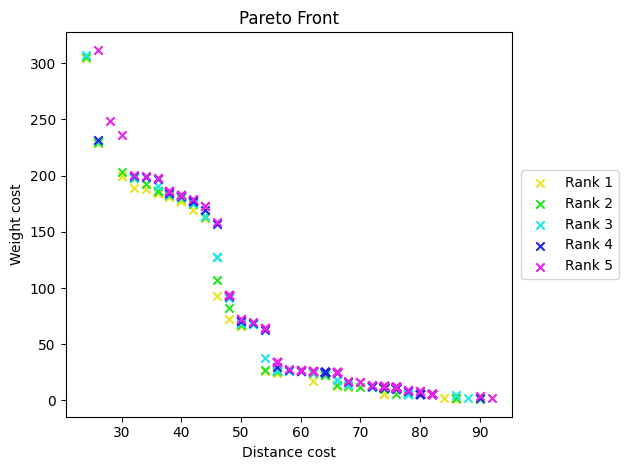

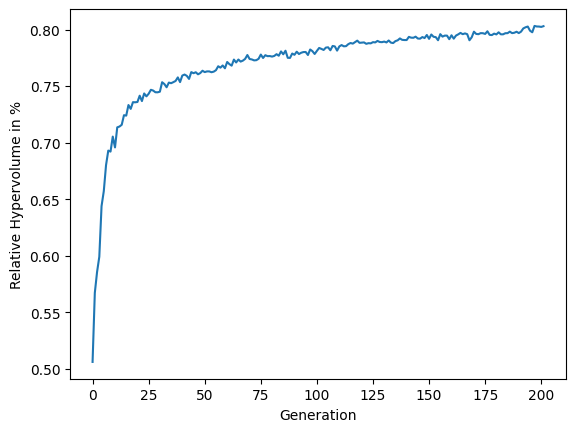

In [5]:
def simple_selection(ranking, population, generation_size):
    ranking = ranking[:generation_size*2]
    parents = [population[rank] for rank in ranking]
    return parents

def evaluate_population_2d(population, shopping_list, J_product):
    # Compute Costs and ranking for population
    weight_costs = [compute_weight_cost(order, shopping_list) for order in population]
    distance_costs = [distance.compute_timecost_from_middle_indices_order(order, J_product) for order in population]
    ranking, pareto_ranks, crowding_distances = pareto_rank_2_with_crowding(distance_costs, weight_costs)
    pareto_front_indices = [i for i, r in enumerate(pareto_ranks) if r == min(pareto_ranks)]
    pareto_front = [population[i] for i in pareto_front_indices]
    return ranking, pareto_front, pareto_ranks, crowding_distances, weight_costs, distance_costs

def crossover_reproduction(selected_population:list):
    # s = len(selected population) = g/2
    # O(g * n)
    number_of_products = len(selected_population[0])
    crossover_line = int(number_of_products/2)
    children = []
    for i in range(0,len(selected_population),2):
        male, female = selected_population[i], selected_population[i+1]
        child = male[:crossover_line]
        while len(child) < len(male):
            child.append(next(product for product in female if (product not in child)))
        children.append(child)
    return children

def replacement_2d(population_size, ranking, population, pareto_front, pareto_ranks, crowding_distances, weight_costs, distance_costs):
    # Reihenfolge nach Ranking
    sorted_indices = ranking[:population_size]  # top N indices
    
    # Population kürzen
    population = [population[i] for i in sorted_indices]
    pareto_ranks = [pareto_ranks[i] for i in sorted_indices]
    weight_costs = [weight_costs[i] for i in sorted_indices]
    distance_costs = [distance_costs[i] for i in sorted_indices]
    crowding_distances = [crowding_distances[i] for i in sorted_indices]

    # Erste Pareto-Front aktualisieren
    min_rank = min(pareto_ranks)
    pareto_front = [population[i] for i, r in enumerate(pareto_ranks) if r == min_rank]

    # Ranking neu setzen (0..population_size-1)
    ranking = list(range(len(population)))

    return population, pareto_front, pareto_ranks, crowding_distances, ranking, weight_costs, distance_costs

def remove_duplicates(population):
    seen = set()
    new_pop = []
    for ind in population:
        key = tuple(ind)
        if key not in seen:
            seen.add(key)
            new_pop.append(ind)
    return new_pop

def hypervolume_2D(cost1, cost2, ref=None):
    import numpy as np
    pts = np.array(list(zip(cost1, cost2)))
    # Minimierung → sortieren nach Cost1
    pts = pts[pts[:,0].argsort()]

    if ref is None:
        ref = (max(cost1)*1.1, max(cost2)*1.1)

    hv = 0
    prev_x = ref[0]
    for x, y in reversed(pts):
        width = prev_x - x
        height = ref[1] - y
        hv += width * height
        prev_x = x
    return hv

def initialize_population_2d(population_size):
    population, population_label = [], []
    for i in range(population_size):
        if i < 0.7*population_size:
            order = order_functions.generate_random_order(len(shopping_list))
            label = "random"
        elif i < 0.8*population_size:
            order = generate_weightgreedy_random_order(shopping_list, alpha = 0.5)
            label = "weight-greedy"
        elif i < 0.9*population_size:
            order = order_functions.generate_distancegreedy_random_order(J_product, alpha = 0.5)
            label = "distance-greedy"
        elif i < 0.95*population_size:
            order,_ = distance.GRASP(J_product, compute_neighbours_func=order_functions.compute_neighbours2, alpha = 0.5)
            label = "GRASP (α = 0.5)"
        else:
            order,_ = distance.GRASP(J_product, compute_neighbours_func=order_functions.compute_neighbours2, alpha = 0.1)
            label = "GRASP (α = 0.1)"
        population.append(order)
        population_label.append(label)
    return population, population_label

def evolution_2d(shopping_list:ShoppingList, J_product, population_size = 100, generation_size = 10, patience = 10, mutation_probability = 0.5, max_generations = 200, reference_point = None, history=False):
    if history:
        history_list = []
    # Generate initial population
    # strategic Multi-Start-Heuristic
    population, _ = initialize_population_2d(population_size)
    
    ranking, pareto_front, pareto_ranks, crowding_distances, weight_costs, distance_costs = evaluate_population_2d(population, shopping_list, J_product)
    if history:
        history_list.append({
            "pareto_ranks": pareto_ranks.copy(),
            "weight_costs": weight_costs.copy(),
            "distance_costs": distance_costs.copy()
        })


    # Computation and set up of Hypervolume
    if reference_point == None:
        reference_point = (max(distance_costs)*1.1, max(weight_costs)*1.1)
    max_hypervolume = reference_point[0] * reference_point[1]
    epsilon = max_hypervolume * 0.001
    hypervolume = hypervolume_2D(distance_costs, weight_costs, reference_point)
    hypervolume_list = [hypervolume]

    termination_criterion = False
    total_rounds = 0
    rounds_without_improvement = 0
    while not termination_criterion:
        if total_rounds == 0:
            plot_pareto_2(pareto_ranks, distance_costs, weight_costs, xlabel="Distance cost", ylabel="Weight cost", max_legend_ranks=6, plot_high_ranks=True, reference_point=None, saving_path="initial_pareto_plot.jpg")

        # Selection
        selected_population = simple_selection(ranking, population, generation_size)

        # Reproduction
        children = crossover_reproduction(selected_population)

        # Mutation
        mutation_rcl = [random.random() < mutation_probability for i in range(len(children))]
        children = [
            order_functions.mutation(children[i]) if mutation_rcl[i] else children[i]
            for i in range(len(children))
        ]        
        # Merging
        population = population + children
        population = remove_duplicates(population)

        # Evaluation
        ranking, pareto_front, pareto_ranks, crowding_distances, weight_costs, distance_costs = evaluate_population_2d(population, shopping_list, J_product)

        # Replacement
        population, pareto_front, pareto_ranks, crowding_distances, ranking, weight_costs, distance_costs = replacement_2d(population_size, ranking, population, pareto_front, pareto_ranks, crowding_distances, weight_costs, distance_costs)

        if history:
            history_list.append({
                "pareto_ranks": pareto_ranks.copy(),
                "weight_costs": weight_costs.copy(),
                "distance_costs": distance_costs.copy()
            })

        new_hypervolume = hypervolume_2D(distance_costs, weight_costs, reference_point)
        # Termination criterion
        if new_hypervolume <= hypervolume + epsilon:
            rounds_without_improvement += 1
        else:
            rounds_without_improvement = 0
        hypervolume = new_hypervolume
        hypervolume_list.append(hypervolume)
        if total_rounds >= max_generations or rounds_without_improvement > patience:
            termination_criterion = True
        total_rounds += 1
        #print(f"[{total_rounds:3}/{max_generations}] - Hypervolume = {int(hypervolume)} - rounds without improvement = {rounds_without_improvement}")
    # Norm hypervolume
    hypervolume_list = [hypervolume/max_hypervolume for hypervolume in hypervolume_list]

    if history:
        return population, pareto_ranks, weight_costs, distance_costs, hypervolume_list, reference_point, history_list
    else:
        return population, pareto_ranks, weight_costs, distance_costs, hypervolume_list, reference_point

reference_point = (200, 400)
population, pareto_ranks, weight_costs, distance_costs, hypervolume_list, reference_point, history_list = evolution_2d(
            shopping_list, J_product, patience=10, generation_size=100, population_size=500, reference_point=reference_point, history=True)
plot_pareto_2(pareto_ranks, distance_costs, weight_costs, xlabel="Distance cost", ylabel="Weight cost",
               max_legend_ranks=6, plot_high_ranks=False, reference_point=None, saving_path="Final_pareto_front.jpg")

plot_hypervolume(hypervolume_list, saving_path="hypervolume.jpg")


In [16]:
import imageio
import os

def create_pareto_gif_from_history(history_list, filename="assets/pareto_evolution.gif", duration=0.5, tmp_folder="_tmp_gif"):
    if not os.path.exists(tmp_folder):
        os.makedirs(tmp_folder)
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    images = []
    tmp_files = []  # <- speichert die Dateipfade

    for gen, gen_data in enumerate(history_list):
        pareto_ranks = gen_data["pareto_ranks"]
        weight_costs = gen_data["weight_costs"]
        distance_costs = gen_data["distance_costs"]
        
        tmp_file = os.path.join(tmp_folder, f"gen_{gen}.png")
        tmp_files.append(tmp_file)
        
        plot_pareto_2(
            pareto_ranks, distance_costs, weight_costs,
            xlabel="Distance cost",
            ylabel="Weight cost",
            max_legend_ranks=6,
            plot_high_ranks=True,
            reference_point=None,
            saving_path=tmp_file
        )
        
        images.append(imageio.imread(tmp_file))
    
    # GIF speichern
    imageio.mimsave(filename, images, duration=duration)
    
    # Temporäre PNGs löschen
    for file_path in tmp_files:
        os.remove(file_path)
    os.rmdir(tmp_folder)
    
    print(f"GIF saved as {filename}")

#create_pareto_gif_from_history(history_list, filename="assets/pareto_evolution.gif", duration=0.5)

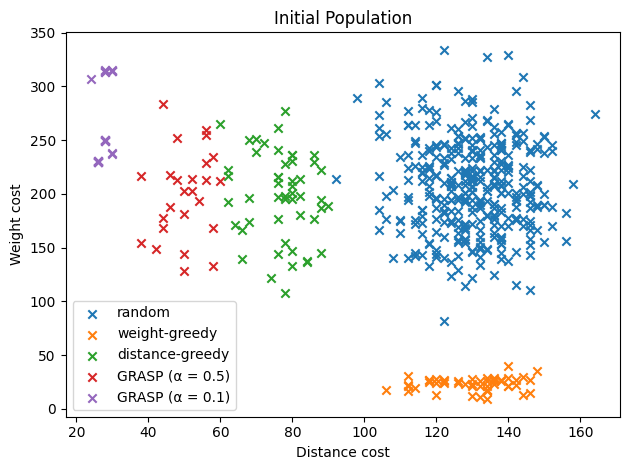

In [28]:
# Visualize initial population
def plot_initial_population(population, population_label, xlabel="Cost x", ylabel="Cost y", saving_path=None):
    _, _, _, _, weight_costs, distance_costs = evaluate_population_2d(
        population, shopping_list, J_product
    )

    # ---- Indizes nach Label gruppieren ----
    label_to_indices = {}
    for i, label in enumerate(population_label):
        if label not in label_to_indices:
            label_to_indices[label] = []
        label_to_indices[label].append(i)

    plt.figure()

    # ---- Über alle Sublists loopen ----
    for label, indices in label_to_indices.items():
        x_vals = [distance_costs[i] for i in indices]
        y_vals = [weight_costs[i] for i in indices]

        plt.scatter(
            x_vals,
            y_vals,
            label=label,
            marker="x"
        )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title("Initial Population")
    plt.legend()
    plt.tight_layout()

    if saving_path is not None:
        plt.savefig(saving_path, bbox_inches="tight", dpi=400)

population, population_label = initialize_population_2d(population_size=500)
plot_initial_population(population, population_label, xlabel="Distance cost", ylabel="Weight cost", saving_path="Initial_population_distribition.jpg")


# Introducing hardness

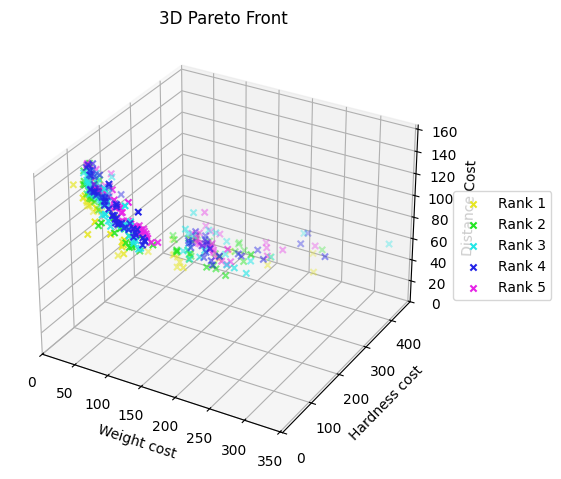

In [34]:

def compute_hardness_cost(order, shopping_list: ShoppingList):
    """
    Crushing penalty:
    If a heavier product is packed later (thus lies on top)
    of a lighter product, a penalty proportional to the
    weight difference is added.
    
    Cost = 0  -> perfectly sorted heavy -> light
    """
    assert len(order) == len(shopping_list)

    total_cost = 0
    hardness_list = []

    for i in range(len(order)):
        product_idx_bottom = order[i]-1 # -1 because order goes from 1 to n but in products we use the index, which starts with 0
        hardness_bottom = shopping_list.products[product_idx_bottom].hardness
        hardness_list.append(hardness_bottom)
        for j in range(i + 1, len(order)):
            product_idx_top = order[j]-1 # -1 because order goes from 1 to n but in products we use the index, which starts with 0
            hardness_top = shopping_list.products[product_idx_top].hardness

            # crushing condition: harder on top of lighter
            if hardness_top > hardness_bottom:
                total_cost += (hardness_top - hardness_bottom)
    #print(f"Weights: {weights_list}")
    return total_cost

def generate_hardness_greedy_order(shopping_list: ShoppingList, alpha=0.5):
    products = shopping_list.products
    n = len(products)

    order = []
    remaining_product_indices = list(range(0, n))  # Produkt-Indizes

    for _ in range(n):
        # Gewichte der noch nicht gewählten Produkte
        hardness_list = [products[i].hardness for i in remaining_product_indices]

        max_hardness = max(hardness_list)
        min_hardness = min(hardness_list)

        # Für heavy-first: obere Grenze definieren
        cutoff_value = max_hardness - alpha * (max_hardness - min_hardness)

        # RCL: alle Produkte mit Gewicht >= cutoff
        rcl = [i for i in remaining_product_indices 
               if products[i].hardness >= cutoff_value]

        winner = random.choice(rcl)

        order.append(winner+1) # order number is index + 1 (because 0 == start)
        remaining_product_indices.remove(winner)
    return order

def pareto_rank_3_with_crowding(cost1, cost2, cost3):
    """
    Computes Pareto ranks for three objectives (minimization) and sorts
    solutions within each front by crowding distance (descending).

    Returns:
        - final_ranking: list of indices sorted by Pareto rank and crowding distance
        - ranks: list of Pareto ranks for each solution (rank 1 = best front)
        - crowding_distances: np.ndarray of crowding distances
    """
    n = len(cost1)
    assert n == len(cost2) == len(cost3)
    
    ranks = [-1] * n
    remaining = set(range(n))
    current_rank = 1
    fronts = []

    # Step 1: Identify Pareto fronts
    while remaining:
        current_front = []
        for i in remaining:
            dominated = False
            for j in remaining:
                if j == i:
                    continue
                if ((cost1[j] <= cost1[i] and cost2[j] <= cost2[i] and cost3[j] <= cost3[i]) and
                    (cost1[j] < cost1[i] or cost2[j] < cost2[i] or cost3[j] < cost3[i])):
                    dominated = True
                    break
            if not dominated:
                current_front.append(i)

        for i in current_front:
            ranks[i] = current_rank
            remaining.remove(i)

        fronts.append(current_front)
        current_rank += 1

    # Step 2: Compute crowding distance for each front
    crowding_distances = np.zeros(n)
    for front in fronts:
        if len(front) == 1:
            crowding_distances[front[0]] = float('inf')
            continue

        front_cost1 = np.array([cost1[i] for i in front])
        front_cost2 = np.array([cost2[i] for i in front])
        front_cost3 = np.array([cost3[i] for i in front])
        
        # Sort by each objective
        sorted1 = np.argsort(front_cost1)
        sorted2 = np.argsort(front_cost2)
        sorted3 = np.argsort(front_cost3)
        
        # Boundaries get infinite distance
        crowding_distances[front[sorted1[0]]] = float('inf')
        crowding_distances[front[sorted1[-1]]] = float('inf')
        crowding_distances[front[sorted2[0]]] = float('inf')
        crowding_distances[front[sorted2[-1]]] = float('inf')
        crowding_distances[front[sorted3[0]]] = float('inf')
        crowding_distances[front[sorted3[-1]]] = float('inf')
        
        # Normalize ranges
        norm1 = front_cost1.max() - front_cost1.min() or 1.0
        norm2 = front_cost2.max() - front_cost2.min() or 1.0
        norm3 = front_cost3.max() - front_cost3.min() or 1.0

        # Interior points
        for k in range(1, len(front)-1):
            crowding_distances[front[sorted1[k]]] += (front_cost1[sorted1[k+1]] - front_cost1[sorted1[k-1]]) / norm1
            crowding_distances[front[sorted2[k]]] += (front_cost2[sorted2[k+1]] - front_cost2[sorted2[k-1]]) / norm2
            crowding_distances[front[sorted3[k]]] += (front_cost3[sorted3[k+1]] - front_cost3[sorted3[k-1]]) / norm3

    # Step 3: Produce final ranking (rank ascending, crowding distance descending)
    all_indices = list(range(n))
    final_ranking = sorted(all_indices, key=lambda i: (ranks[i], -crowding_distances[i]))

    return final_ranking, ranks, crowding_distances

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
import numpy as np

def plot_pareto_3(ranks, cost1, cost2, cost3,
                  xlabel="Cost 1", ylabel="Cost 2", zlabel="Cost 3",
                  max_legend_ranks=5, plot_high_ranks=True,
                  reference_point=None, saving_path = None):
    """
    3D Pareto Front Plot for 3 objectives.

    - First max_legend_ranks fronts get distinct colors + legend entry
    - Remaining fronts plotted in black with single legend entry "Rank ≥ max_legend_ranks"
    - reference_point: tuple/list (x, y, z) to mark a reference in red
    """
    max_rank = max(ranks)
    colors = [mcolors.hsv_to_rgb((i / max_legend_ranks, 0.85, 0.9)) for i in range(max_legend_ranks)]
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    black_plotted = False

    for r in range(1, max_rank + 1):
        indices = [i for i in range(len(ranks)) if ranks[i] == r]
        xs = [cost1[i] for i in indices]
        ys = [cost2[i] for i in indices]
        zs = [cost3[i] for i in indices]

        if r < max_legend_ranks:
            ax.scatter(xs, ys, zs, color=colors[r], marker='x', label=f"Rank {r}")
        elif plot_high_ranks:
            label = f"Rank ≥ {max_legend_ranks}" if not black_plotted else None
            ax.scatter(xs, ys, zs, color="black", marker='x', label=label)
            black_plotted = True

    if reference_point is not None:
        ax.scatter(reference_point[0], reference_point[1], reference_point[2],
                   color="red", marker="x", s=100, label="Reference-point")
    # Set axes to start at 0
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_zlim(bottom=0)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)

    ax.set_title("3D Pareto Front")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    if saving_path is not None:
        plt.savefig(saving_path, bbox_inches="tight", dpi=400)


m = 1000
weight_costs, hardness_costs, distance_costs = [], [], []
for i in range(m):
    if i < m/3:
        order = generate_weightgreedy_random_order(shopping_list, alpha = 0.5)
    elif i < 2/3*m:
        order = generate_hardness_greedy_order(shopping_list, alpha=0.5)
    else:
        order = order_functions.generate_distancegreedy_random_order(J_product, alpha = 0.5)
    weight_cost = compute_weight_cost(order, shopping_list)
    weight_costs.append(weight_cost)
    hardness_cost = compute_hardness_cost(order, shopping_list)
    hardness_costs.append(hardness_cost)
    distance_cost = distance.compute_timecost_from_middle_indices_order(order, J_product)
    distance_costs.append(distance_cost)
import matplotlib.pyplot as plt
final_ranking, ranks, crowding_distances = pareto_rank_3_with_crowding(weight_costs, hardness_costs, distance_costs)
plot_pareto_3(ranks, weight_costs, hardness_costs, distance_costs, xlabel="Weight cost", ylabel="Hardness cost", zlabel = "Distance Cost", max_legend_ranks=6, plot_high_ranks=False)


# 3D Evolution

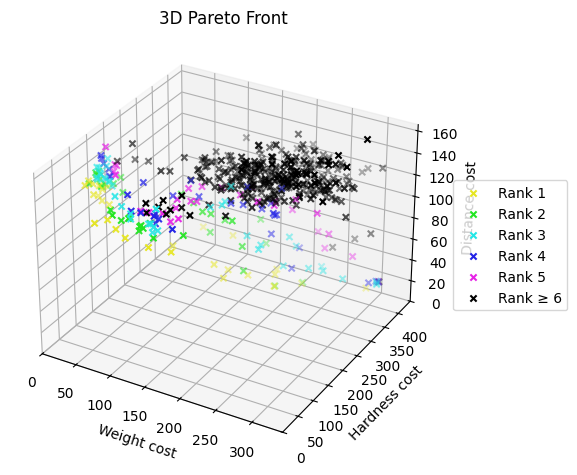

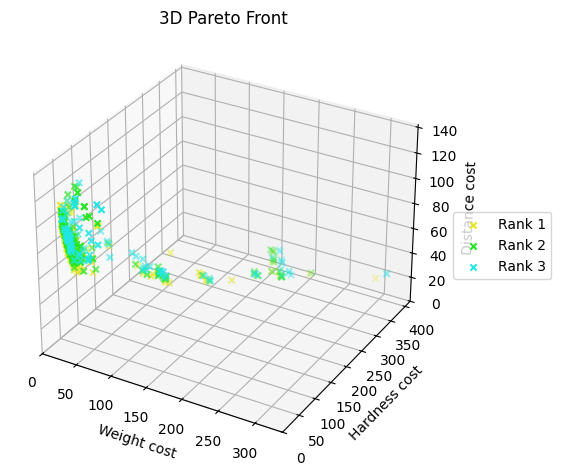

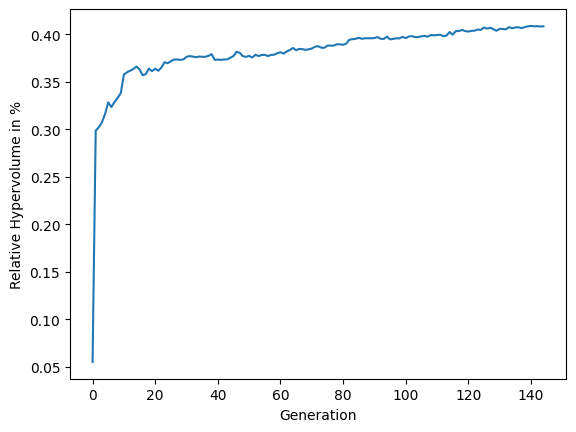

In [35]:
def initialize_population_3d(population_size):
    population = []
    for i in range(population_size):
        if i < 0.7*population_size:
            order = order_functions.generate_random_order(len(shopping_list))
        elif i < 0.8*population_size:
            order = generate_weightgreedy_random_order(shopping_list, alpha = 0.5)
        elif i < 0.9*population_size:
            order = generate_hardness_greedy_order(shopping_list, alpha = 0.5)
        elif i < 0.93*population_size:
            order = order_functions.generate_distancegreedy_random_order(J_product, alpha = 0.5)
        elif i < 0.97*population_size:
            order,_ = distance.GRASP(J_product, compute_neighbours_func=order_functions.compute_neighbours2, alpha = 0.5)
        else:
            order,_ = distance.GRASP(J_product, compute_neighbours_func=order_functions.compute_neighbours2, alpha = 0.1)
        population.append(order)
    return population

def evaluate_population_3d(population, shopping_list, J_product):
    # Compute Costs and ranking for population
    weight_costs = [compute_weight_cost(order, shopping_list) for order in population]
    hardness_costs = [compute_hardness_cost(order, shopping_list) for order in population]
    distance_costs = [distance.compute_timecost_from_middle_indices_order(order, J_product) for order in population]

    ranking, pareto_ranks, crowding_distances = pareto_rank_3_with_crowding(distance_costs, weight_costs, hardness_costs)
    pareto_front_indices = [i for i, r in enumerate(pareto_ranks) if r == min(pareto_ranks)]
    pareto_front = [population[i] for i in pareto_front_indices]
    return ranking, pareto_front, pareto_ranks, crowding_distances, weight_costs, hardness_costs, distance_costs


def hypervolume_3D(cost1, cost2, cost3, ref=None):
    pts = np.array(list(zip(cost1, cost2, cost3)))
    # nach cost1 sortieren
    pts = pts[pts[:,0].argsort()]
    if ref is None:
        ref = (
            max(cost1) * 1.1,
            max(cost2) * 1.1,
            max(cost3) * 1.1
        )
    hv = 0
    prev_x = ref[0]
    # von hinten durchgehen (schlechteste Lösungen zuerst)
    for i in range(len(pts)-1, -1, -1):
        x = pts[i,0]
        width = prev_x - x
        # Punkte, die diese Scheibe dominieren
        slice_pts = pts[:i+1]
        yz_hv = hypervolume_2D(
            slice_pts[:,1],
            slice_pts[:,2],
            ref=(ref[1], ref[2])
        )
        hv += width * yz_hv
        prev_x = x
    return hv

def replacement_3d(population_size, ranking, population, pareto_front, pareto_ranks, crowding_distances, weight_costs, hardness_costs, distance_costs):
    # Reihenfolge nach Ranking
    sorted_indices = ranking[:population_size]  # top N indices
    
    # Population kürzen
    population = [population[i] for i in sorted_indices]
    pareto_ranks = [pareto_ranks[i] for i in sorted_indices]
    weight_costs = [weight_costs[i] for i in sorted_indices]
    hardness_costs = [hardness_costs[i] for i in sorted_indices]
    distance_costs = [distance_costs[i] for i in sorted_indices]
    crowding_distances = [crowding_distances[i] for i in sorted_indices]

    # Erste Pareto-Front aktualisieren
    min_rank = min(pareto_ranks)
    pareto_front = [population[i] for i, r in enumerate(pareto_ranks) if r == min_rank]

    # Ranking neu setzen (0..population_size-1)
    ranking = list(range(len(population)))

    return population, pareto_front, pareto_ranks, crowding_distances, ranking, weight_costs, hardness_costs, distance_costs

def evolution_3d(shopping_list:ShoppingList, J_product, population_size = 100, generation_size = 10, patience = 10, mutation_probability = 0.5, max_generations = 200, reference_point = None):
    # Generate initial population
    # strategic Multi-Start-Heuristic
    population = initialize_population_3d(population_size)
    
    ranking, pareto_front, pareto_ranks, crowding_distances, weight_costs, hardness_costs, distance_costs = evaluate_population_3d(population, shopping_list, J_product)
    
    # Computation and set up of Hypervolume
    if reference_point == None:
        reference_point = (max(distance_costs)*1.1, max(weight_costs)*1.1)
    max_hypervolume = reference_point[0] * reference_point[1] * reference_point[2]
    epsilon = max_hypervolume * 0.001
    hypervolume = hypervolume_3D(distance_costs, weight_costs, reference_point)
    hypervolume_list = [hypervolume]

    termination_criterion = False
    total_rounds = 0
    rounds_without_improvement = 0
    while not termination_criterion:
        if total_rounds == 0:
            plot_pareto_3(pareto_ranks, weight_costs, hardness_costs, distance_costs, xlabel="Weight cost", ylabel="Hardness cost", zlabel="Distance cost", max_legend_ranks=6, plot_high_ranks=True, reference_point=None)

        # Selection
        selected_population = simple_selection(ranking, population, generation_size)

        # Reproduction
        children = crossover_reproduction(selected_population)

        # Mutation
        mutation_rcl = [random.random() < mutation_probability for i in range(len(children))]
        children = [
            order_functions.mutation(children[i]) if mutation_rcl[i] else children[i]
            for i in range(len(children))
        ]        
        # Merging
        population = population + children
        population = remove_duplicates(population)

        # Evaluation
        ranking, pareto_front, pareto_ranks, crowding_distances, weight_costs, hardness_costs, distance_costs = evaluate_population_3d(population, shopping_list, J_product)
        # Replacement
        population, pareto_front, pareto_ranks, crowding_distances, ranking, weight_costs, hardness_costs, distance_costs = replacement_3d(population_size, ranking, population, pareto_front, pareto_ranks, crowding_distances, weight_costs, hardness_costs, distance_costs)
        new_hypervolume = hypervolume_3D(distance_costs, weight_costs, hardness_costs, reference_point)
        # Termination criterion
        if new_hypervolume <= hypervolume + epsilon:
            rounds_without_improvement += 1
        else:
            rounds_without_improvement = 0
        hypervolume = new_hypervolume
        hypervolume_list.append(hypervolume)
        if total_rounds >= max_generations or rounds_without_improvement > patience:
            termination_criterion = True
        total_rounds += 1
        #print(f"[{total_rounds:3}/{max_generations}] - Hypervolume = {int(hypervolume)} - rounds without improvement = {rounds_without_improvement}")
    # Norm hypervolume
    hypervolume_list = [hypervolume/max_hypervolume for hypervolume in hypervolume_list]


    return population, pareto_ranks, ranking, weight_costs, hardness_costs, distance_costs, hypervolume_list, reference_point

reference_point = (200, 400, 500)
population, pareto_ranks, ranking, weight_costs, hardness_costs, distance_costs, hypervolume_list, reference_point = evolution_3d(
            shopping_list, J_product, patience=10, generation_size=100, population_size=500, reference_point=reference_point)
plot_pareto_3(pareto_ranks, weight_costs, hardness_costs, distance_costs, xlabel="Weight cost", ylabel="Hardness cost", zlabel="Distance cost", max_legend_ranks=6, plot_high_ranks=True, reference_point=None, saving_path = "pareto_front_3d.jpg")
plot_hypervolume(hypervolume_list, saving_path="hypervolume_3d.jpg")


In [31]:
def filter_best_pareto_rank(population, pareto_ranks, ranking, weight_costs, hardness_costs, distance_costs):
    # ---- Pareto Rank 1 filtern ----
    best_rank = min(pareto_ranks)
    pareto_indices = [i for i, r in enumerate(pareto_ranks) if r == best_rank]

    population = [population[i] for i in pareto_indices]
    weight_costs = [weight_costs[i] for i in pareto_indices]
    hardness_costs = [hardness_costs[i] for i in pareto_indices]
    distance_costs = [distance_costs[i] for i in pareto_indices]

    pareto_ranks = [pareto_ranks[i] for i in pareto_indices]
    ranking = list(range(len(population)))  # neues Ranking
    return population, pareto_ranks, ranking, weight_costs, hardness_costs, distance_costs

def normalize_cost(cost_list):
    min_cost = min(cost_list)
    max_cost = max(cost_list)

    # vermeiden von Division durch 0
    if max_cost == min_cost:
        return [0.0 for _ in cost_list]

    normalized = [(c - min_cost) / (max_cost - min_cost) for c in cost_list]
    return normalized

def weighted_sum(normalized_costs: list, weights: list):  
    return np.array(normalized_costs) @ np.array(weights)

def weighted_sum_for_list(cost_lists: list, weights:list):
    return (np.array(weights) @ np.array(cost_lists)).tolist()


ORDER COSTS: Distance = 58 (0.34) | Weight = 45 (0.15) | Hardness = 63 (0.16)
['Water', 'Orange Juice', 'Spezi', 'Beer', 'Baguette', 'Tuna', 'Salmon', 'Pizza', 'Frozen Burritos', 'Chocolate', 'Tabasco', 'Chicken Breast', 'Sausage', 'Cheddar', 'Cashews', 'Almonds', 'Mozzarella', 'Lasagna', 'Soy Milk', 'Broccoli', 'Carrot', 'Flowers', 'Apple', 'Banana', 'Croissant', 'Toiletpaper', 'Cracker']
Weights in order:                   [4, 3, 3, 5, 2, 3, 3, 3, 3, 2, 1, 3, 3, 2, 1, 1, 2, 3, 2, 2, 1, 1, 1, 1, 1, 2, 1]
Hardness in order:                  [5, 5, 5, 5, 2, 5, 3, 4, 4, 3, 5, 2, 4, 3, 4, 4, 2, 4, 3, 2, 3, 1, 2, 1, 1, 1, 2]
Distance between products:          [4, 1, 1, 1, 1, 4, 1, 6, 1, 2, 5, 1, 0, 1, 2, 0, 2, 4, 1, 2, 0, 2, 1, 0, 7, 4, 1, 3]
Mean path length between each step: 2.0714285714285716


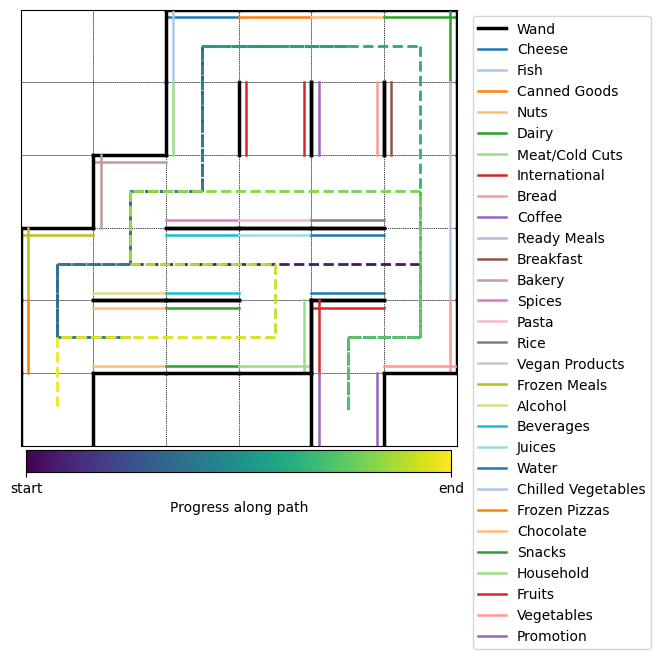

In [39]:
# Filter Pareto-Rank 1
population, pareto_ranks, ranking, weight_costs, hardness_costs, distance_costs = filter_best_pareto_rank(population, pareto_ranks, ranking, weight_costs, hardness_costs, distance_costs)


# Normalize Costs
norm_distance_costs = normalize_cost(distance_costs)
norm_weight_costs = normalize_cost(weight_costs)
norm_hardness_costs = normalize_cost(hardness_costs)

# Weighted sum
weights = [0.6, 0.3, 0.1] # Distance, Weight, Hardness
scores = weighted_sum_for_list(cost_lists = [norm_distance_costs, norm_weight_costs, norm_hardness_costs], weights=weights)
ind = scores.index(min(scores))
#print(min(scores))

# Order & Costs
order = population[ind]
distance_cost, norm_distance_cost = distance_costs[ind], norm_distance_costs[ind]
weight_cost, norm_weight_cost = weight_costs[ind], norm_weight_costs[ind]
hardness_cost, norm_hardness_cost = hardness_costs[ind], norm_hardness_costs[ind]
print(f"ORDER COSTS: Distance = {distance_cost} ({round(norm_distance_cost,2)}) | Weight = {weight_cost} ({round(norm_weight_cost,2)}) | Hardness = {hardness_cost} ({round(norm_hardness_cost,2)})")

# Products
index_to_product = {v: k for k, v in shopping_list.product_indizes.items()}
products_in_order = [index_to_product[i] for i in order]
print(products_in_order)

# Weight and Hardness
# Mapping Name -> Produktobjekt
product_lookup = {p.name: p for p in shopping_list.products}

# Hardness und Weight in der gleichen Reihenfolge wie die Route
weights_in_order = [product_lookup[name].weight for name in products_in_order]
hardness_in_order = [product_lookup[name].hardness for name in products_in_order]

label_width = 35  # Breite der Labels für Ausrichtung
print(f"{'Weights in order:':<{label_width}} {weights_in_order}")
print(f"{'Hardness in order:':<{label_width}} {hardness_in_order}")

#Path
path = order_functions.get_path_from_middle_indices_order(order, P_product)
#print(path)

# Mean path length
path_length_between_each_step = [len(x)-1 for x in path]
print(f"{'Distance between products:':<{label_width}} {path_length_between_each_step}")
print(f"Mean path length between each step: {np.mean(path_length_between_each_step)}")

# Plot
saving_path = f"path_3d_d{distance_cost}_w{weight_cost}_h{hardness_cost}|d{weights[0]}_w{weights[1]}_h{weights[2]}.jpg"
grid.plot(path, saving_path=saving_path)